<a href="https://colab.research.google.com/github/eeolga/article/blob/main/144_Preparation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

The e-course taxonomy

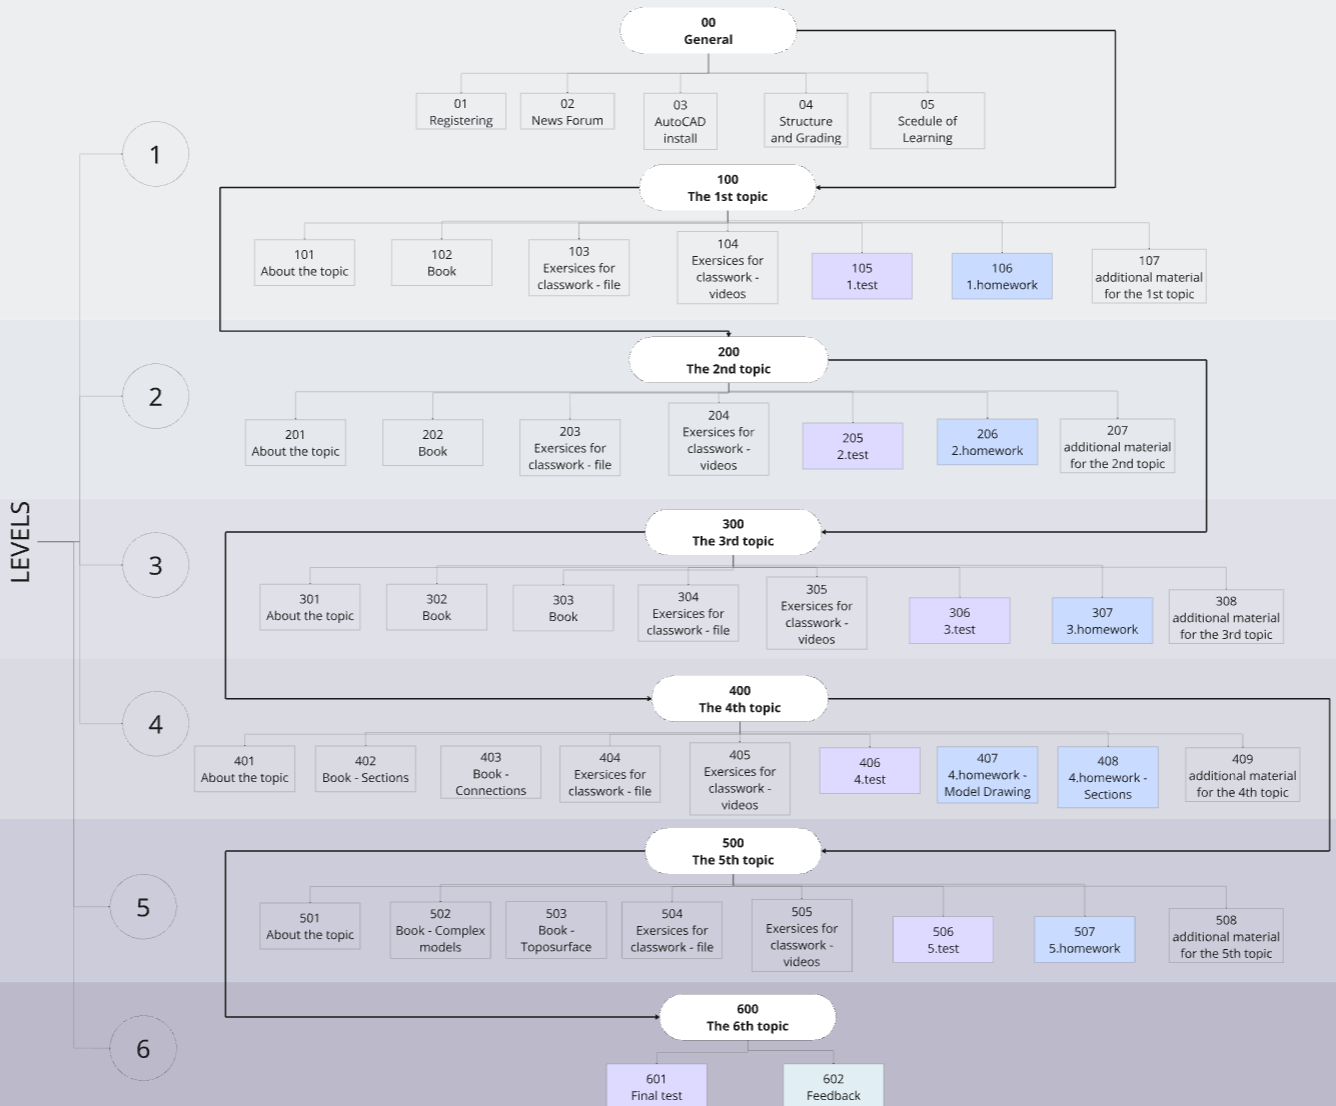

In [1]:
from IPython.display import Image
Image('/content/taxonomy.png')

Moodle extracted e-course logs pre-processing

In [ ]:
import pandas as pd
import re

In [ ]:
# Load the Excel file
df = pd.read_excel('/content/144.xlsx')

In [ ]:
# Delete specified columns
columns_to_delete = ['Time','User full name','Affected user', 'Event name', 'Origin', 'IP address']
df = df.drop(columns=[col for col in columns_to_delete if col in df.columns])

In [ ]:
# Rename 'Event context' to 'tool_code'
if 'Event context' in df.columns:
    df = df.rename(columns={'Event context': 'tool_code'})

In [ ]:

# Extract the last number from 'Description' and replace 'tool_code' data
if 'Description' in df.columns:

    # Extract last number for 'tool_code'
    df['tool_code'] = df['Description'].str.extract(r'(\d+)\D*$').fillna('')

# Delete the 'Description' column
df = df.drop(columns=['Description'], errors='ignore')

In [ ]:
# Display the first few rows of the updated DataFrame
display(df.head())

# Save the updated data to 144_1.xlsx
df.to_excel('/content/144_1.xlsx', index=False)
print("Data successfully processed and saved to '144_1.xlsx'")

,tool_code,Component
0,6316,H5P Package
1,319388,Assignment
2,319388,Assignment
3,285951,Assignment
4,285950,Assignment


Data successfully processed and saved to '144_1.xlsx'
Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


In [ ]:
# Load the data from 144_1.xlsx
df_prep1 = pd.read_excel('/content/144_1.xlsx')

In [ ]:
if 'tool_code' in df_prep1.columns and 'Component' in df_prep1.columns:
    grouped_df = df_prep1.groupby(['tool_code', 'Component']).size().reset_index(name='count')
    display(grouped_df.head())
elif 'tool_code' not in df_prep1.columns:
    print("'tool_code' column not found, unable to group.")
    grouped_df = pd.DataFrame()
elif 'Component' not in df_prep1.columns:
    print("'Component' column not found, unable to group.")
    grouped_df = pd.DataFrame()

,tool_code,Component,count
0,665.0,User tours,6
1,2025.0,Forum,1
2,4154.0,H5P Package,13
3,4241.0,H5P Package,54
4,4457.0,H5P Package,106


In [ ]:
# Save the updated data to preparation_2.xlsx
if not grouped_df.empty:
    grouped_df.to_excel('/content/144_2.xlsx', index=False)
    print("Data successfully processed and saved to '144_2.xlsx'")
else:
    print("No data to save to '144_2.xlsx' as 'tool_code' column was not found or DataFrame is empty.")

Data successfully processed and saved to '144_2.xlsx'


##  `144_dataset.xlsx`



In [6]:
import pandas as pd
# Load the new Excel dataset
df_dataset = pd.read_excel('/content/144_dataset.xlsx')

print("Original DataFrame info for 144_dataset.xlsx:")
df_dataset.info()
display(df_dataset.head())

Original DataFrame info for 144_dataset.xlsx:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47 entries, 0 to 46
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   count                    47 non-null     int64  
 1   name                     46 non-null     object 
 2   code                     46 non-null     float64
 3   level                    46 non-null     float64
 4   level_scaled             47 non-null     float64
 5   difficulty
weight,
WDi   47 non-null     float64
 6   logs                     47 non-null     int64  
 7   WLi                      47 non-null     float64
 8   time, Tresource          47 non-null     float64
 9   time weight norm, 
WTi   47 non-null     float64
 10  success indicator,
Si    47 non-null     float64
dtypes: float64(8), int64(2), object(1)
memory usage: 4.2+ KB


,count,name,code,level,level_scaled,"difficulty\nweight,\nWDi",logs,WLi,"time, Tresource","time weight norm, \nWTi","success indicator,\nSi"
0,1,registering,1.0,1.0,0.01,0.007246,124,0.004677,4.521739,2.26087,1.133287
1,1,Forum for news,2.0,1.0,0.01,0.007246,52,0.001961,4.521739,2.26087,1.132472
2,1,structure and grading,3.0,1.0,0.01,0.007246,6,0.000226,4.521739,2.26087,1.131952
3,1,AutoCAD install link,4.0,1.0,0.01,0.007246,78,0.002942,4.521739,2.26087,1.132767
4,1,Scedule of learning,5.0,1.0,0.01,0.007246,13,0.000490,4.521739,2.26087,1.132031


In [7]:
# Delete specified columns (these columns are not present in 144_dataset.xlsx, so this step will do nothing)
columns_to_delete_dataset = ['Time','User full name','Affected user', 'Event name', 'Origin', 'IP address']
df_dataset = df_dataset.drop(columns=[col for col in columns_to_delete_dataset if col in df_dataset.columns])

# Rename 'code' to 'tool_code' and 'name' to 'Component' to align with previous data processing
if 'code' in df_dataset.columns:
    df_dataset = df_dataset.rename(columns={'code': 'tool_code'})
if 'name' in df_dataset.columns:
    df_dataset = df_dataset.rename(columns={'name': 'Component'})

# The 'Event context' and 'Description' columns are not present in this dataset,
# so the original logic for them is removed or will not execute.

print("DataFrame after initial pre-processing:")
display(df_dataset.head())

DataFrame after initial pre-processing:


,count,Component,tool_code,level,level_scaled,"difficulty\nweight,\nWDi",logs,WLi,"time, Tresource","time weight norm, \nWTi","success indicator,\nSi"
0,1,registering,1.0,1.0,0.01,0.007246,124,0.004677,4.521739,2.26087,1.133287
1,1,Forum for news,2.0,1.0,0.01,0.007246,52,0.001961,4.521739,2.26087,1.132472
2,1,structure and grading,3.0,1.0,0.01,0.007246,6,0.000226,4.521739,2.26087,1.131952
3,1,AutoCAD install link,4.0,1.0,0.01,0.007246,78,0.002942,4.521739,2.26087,1.132767
4,1,Scedule of learning,5.0,1.0,0.01,0.007246,13,0.000490,4.521739,2.26087,1.132031
